***Nama : Rambu Marshanda Tamu Ina Paa***

***NIM : 20254920004***

# PENDAHULUAN

Perkembangan teknologi mendorong pemanfaatan data dalam industri properti untuk menghasilkan keputusan yang lebih akurat. Perusahaan pemetaan perumahan di California memanfaatkan data yang mencakup faktor ekonomi, demografis, dan geografis seperti pendapatan, jumlah penduduk, karakteristik rumah, serta lokasi wilayah. Oleh karena itu, analisis terhadap California Housing Dataset dilakukan untuk memahami faktor-faktor yang memengaruhi nilai rumah. Dengan menggunakan variabel-variabel tersebut, diharapkan dapat dibangun model yang mampu memprediksi harga rumah secara lebih tepat dan mendukung pengambilan keputusan berbasis data.

# IMPORT DATA

In [9]:
import pandas as pd

df = pd.read_excel("california_housing.xlsx")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


# SOAL 1

## a. Apa itu EDA(Exploratory Data Analysis)?

EDA (Exploratory Data Analysis) adalah proses melihat dan memahami data terlebih dahulu sebelum dianalisis lebih lanjut. Biasanya dilakukan dengan:
- melihat grafik
- mencari pola
- mengecek data aneh

## b. Kenapa EDA penting?

EDA (Exploratory Data Analysis) penting dilakukan karena membantu kita memahami kondisi data sebelum analisis lebih lanjut, seperti mengetahui apakah data tersebar secara normal atau tidak, menemukan adanya kesalahan atau nilai yang tidak wajar (outlier), serta memberikan gambaran awal tentang pola dalam data sehingga kita dapat menentukan metode analisis yang paling tepat untuk digunakan.


## c. Pada California Housing Dataset variabel mana yang kemungkinan bisa dilakukan analisis distribusi data, analisis korelasi, dan analisis regresi?

Variabel yang dapat digunakan dalam analisis distribusi, korelasi, dan regresi pada California Housing Dataset adalah variabel yang berbentuk numerik, yaitu **MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, dan MedHouseVal**. Variabel-variabel ini memiliki nilai berupa angka sehingga dapat diolah secara statistik untuk melihat pola sebaran data, hubungan antar variabel, serta pengaruhnya dalam membentuk suatu model prediksi. Misalnya, **MedInc (pendapatan)** sering digunakan untuk melihat pengaruh tingkat ekonomi terhadap **MedHouseVal (harga rumah)** sebagai variabel target. Sementara itu, variabel seperti jumlah ruangan, jumlah kamar tidur, dan jumlah penduduk dapat memberikan gambaran kondisi lingkungan dan kepadatan hunian. Dengan menganalisis variabel-variabel tersebut, kita dapat memahami faktor-faktor yang memengaruhi harga rumah serta membangun model yang mampu memprediksi nilai properti secara lebih akurat.


## d. Kenapa Latitude & Longitude tidak dipakai?

Variabel **Latitude** dan **Longitude** tidak dimasukkan dalam analisis distribusi, korelasi, maupun regresi karena kedua variabel tersebut hanya menunjukkan lokasi geografis suatu wilayah dalam bentuk koordinat, bukan karakteristik yang secara langsung memengaruhi harga rumah. Nilai dari koordinat ini tidak memiliki makna hubungan linear yang jelas terhadap variabel lain seperti pendapatan atau jumlah kamar, sehingga sulit diinterpretasikan dalam analisis statistik biasa. Selain itu, data lokasi lebih tepat digunakan dalam visualisasi berbasis peta untuk melihat persebaran wilayah, bukan untuk mencari hubungan matematis secara langsung. Oleh karena itu, variabel ini biasanya tidak digunakan dalam analisis utama seperti distribusi, korelasi, dan regresi.


# SOAL 2 : Visualisasi data numerik dari dataset California Housing

## a. Histogram

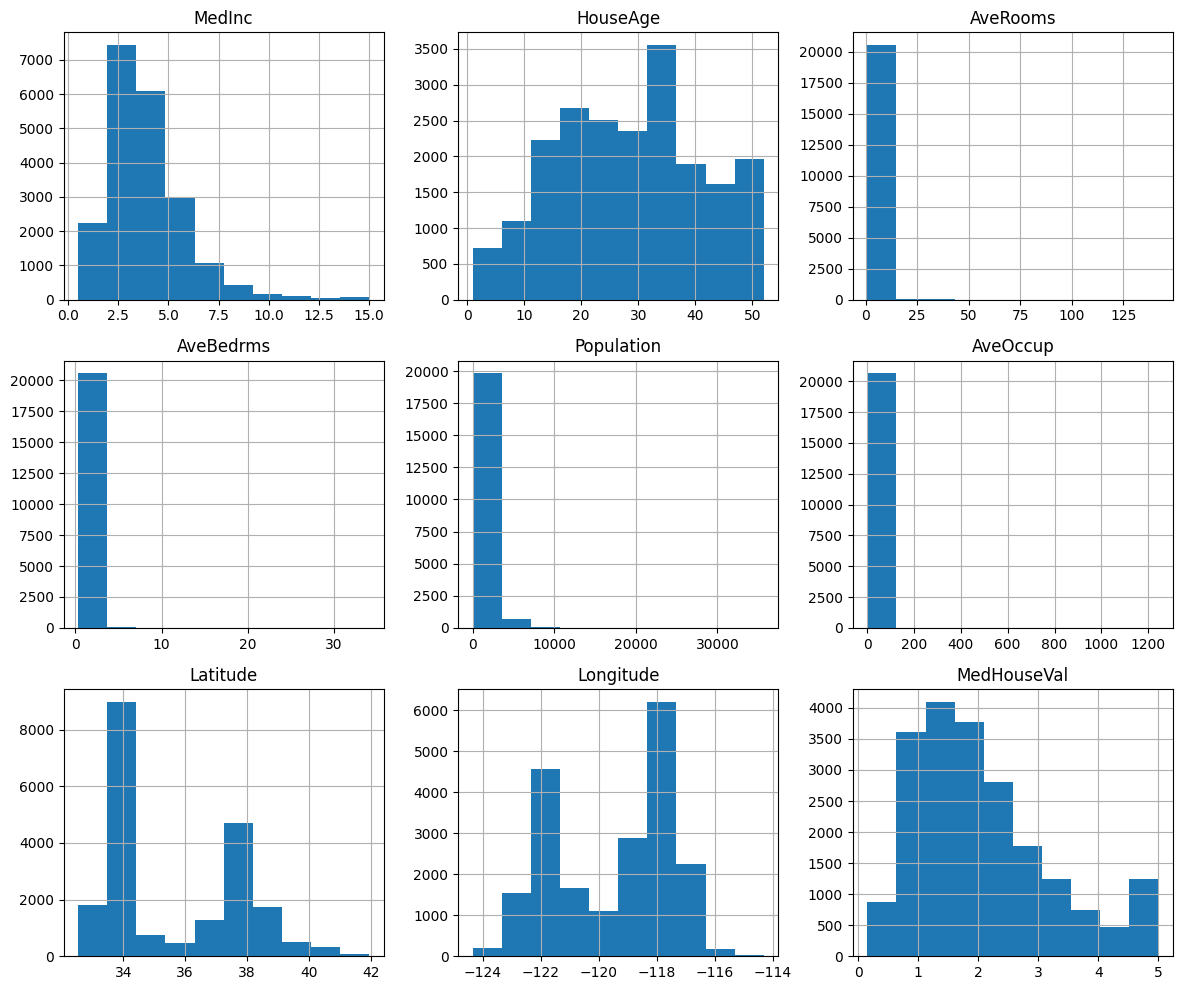

In [12]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Dari grafik histogram di atas, dapat dilihat bahwa sebagian besar data berkumpul pada nilai tertentu, sementara hanya sedikit yang memiliki nilai sangat tinggi. Pada AveRooms, AveBedrms, Population, dan AveOccup, sebagian besar nilainya kecil, namun terdapat beberapa data dengan nilai yang sangat besar (outlier). Variabel MedInc menunjukkan bahwa pendapatan banyak berada pada tingkat menengah ke bawah. Variabel MedHouseVal menunjukkan bahwa harga rumah sebagian besar berada pada kisaran rendah hingga sedang, dengan sedikit yang sangat tinggi. Sementara itu, Latitude dan Longitude menunjukkan sebaran lokasi geografis yang terkonsentrasi pada rentang tertentu di California. Secara keseluruhan, histogram ini menunjukkan bahwa data memiliki banyak ketidakseimbangan dan outlier, sehingga perlu perhatian lebih dalam analisis lanjutan seperti regresi.

## b. Scatter Plot

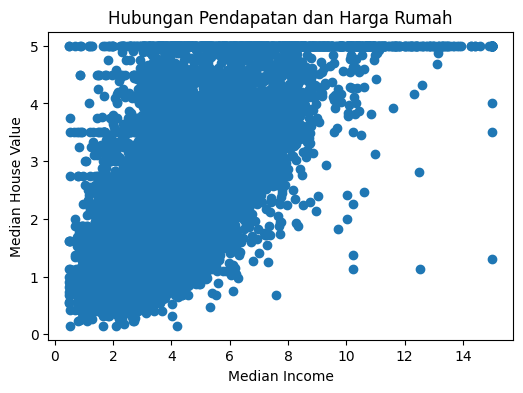

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Hubungan Pendapatan dan Harga Rumah')
plt.show()

Grafik scatter plot di atas menunjukkan hubungan antara **MedInc** (pendapatan) dan **MedHouseVal** (harga rumah). Dari grafik terlihat bahwa semakin tinggi nilai **MedInc**, maka nilai **MedHouseVal** juga cenderung meningkat, yang berarti daerah dengan pendapatan lebih tinggi biasanya memiliki harga rumah yang lebih mahal. Namun, titik-titik pada grafik tidak membentuk garis yang rapi, melainkan menyebar, sehingga hubungan ini tidak sempurna (masih dipengaruhi faktor lain). Selain itu, terlihat juga bahwa ada batas maksimum pada **MedHouseVal**, di mana banyak data berhenti di nilai tertentu, sehingga membentuk garis datar di bagian atas. Secara sederhana, dapat disimpulkan bahwa pendapatan berpengaruh terhadap harga rumah, tetapi bukan satu-satunya faktor yang menentukan.


# SOAL 3 :Menampilkan korelasi antar variabel numerik dalam dataset California Housing

In [18]:
# Hitung Korelasi
corr = df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


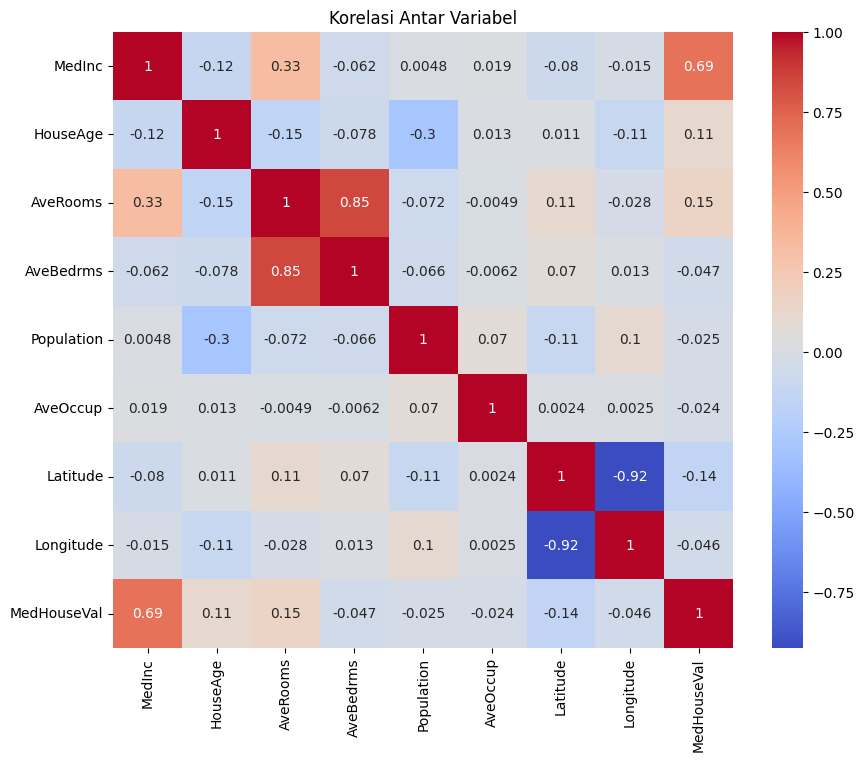

In [20]:
# Visualisasi dengan Heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

Grafik ini menunjukkan hubungan antar variabel, di mana nilai mendekati 1 berarti hubungan kuat dan mendekati 0 berarti lemah. Terlihat bahwa **MedInc** memiliki hubungan paling kuat dengan **MedHouseVal**, artinya semakin tinggi pendapatan, harga rumah cenderung semakin tinggi. Selain itu, **AveRooms** dan **AveBedrms** juga memiliki hubungan kuat karena jumlah ruangan biasanya sejalan dengan jumlah kamar tidur. Sementara variabel lain seperti **Population** dan **AveOccup** memiliki hubungan yang lemah, sehingga pengaruhnya kecil terhadap harga rumah. Secara sederhana, pendapatan adalah faktor yang paling berpengaruh terhadap harga rumah.


In [21]:
# Menampilkan korelasi tertinggi & terendah ke MedHouseVal
corr_target = corr['MedHouseVal'].sort_values(ascending=False)
print(corr_target)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


Data tersebut menunjukkan bahwa **MedInc** (pendapatan) memiliki pengaruh paling besar terhadap **MedHouseVal** (harga rumah), artinya semakin tinggi pendapatan, harga rumah cenderung lebih mahal. Sementara variabel lain seperti **AveRooms, HouseAge, Population, AveOccup, Latitude,** dan **Longitude** memiliki hubungan yang lemah atau sangat kecil, sehingga pengaruhnya tidak terlalu signifikan.


# SOAL 4 : Analisis regresi berganda & R-squared

In [32]:
# Analisis regresi berganda
import statsmodels.api as sm

X = df[['HouseAge', 'AveRooms', 'AveBedrms', 
        'Population', 'AveOccup']]  
y = df['MedInc']

X = sm.add_constant(X)

# Model regresi
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     4402.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:29:45   Log-Likelihood:                -35041.
No. Observations:               20640   AIC:                         7.009e+04
Df Residuals:                   20634   BIC:                         7.014e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4780      0.040     87.452      0.0

Hasil ini menunjukkan bahwa model mampu menjelaskan sekitar **51% variasi pendapatan (MedInc)**, sehingga cukup baik meskipun belum sempurna. Dari semua variabel, **AveRooms** memiliki pengaruh positif paling besar, artinya semakin banyak ruangan, pendapatan cenderung lebih tinggi. Sebaliknya, **AveBedrms** memiliki pengaruh negatif yang kuat, yang menunjukkan bahwa dalam kondisi tertentu, semakin banyak kamar tidur justru berkaitan dengan pendapatan yang lebih rendah. Variabel **Population** dan **AveOccup** juga berpengaruh, tetapi sangat kecil, sedangkan **HouseAge** hampir tidak berpengaruh karena nilainya mendekati nol. Secara sederhana, jumlah dan jenis ruangan rumah lebih berhubungan dengan tingkat pendapatan dibandingkan faktor lainnya, meskipun masih ada faktor lain di luar model yang juga memengaruhi pendapatan.

In [33]:
# R-Square
print("R-Square:", model.rsquared)
print("Adjusted R-Square:", model.rsquared_adj)

R-Square: 0.5161211543829297
Adjusted R-Square: 0.516003901585213


Nilai **R-Square sebesar 0.516** menunjukkan bahwa model mampu menjelaskan sekitar **51% variasi pendapatan (MedInc)** berdasarkan variabel yang digunakan, sehingga model ini sudah cukup baik tetapi belum sepenuhnya akurat. Nilai **Adjusted R-Square yang hampir sama (0.516)** menandakan bahwa variabel yang digunakan sudah cukup relevan dan tidak banyak yang “sia-sia” dalam model. Secara sederhana, model ini sudah bisa memberikan gambaran tentang faktor yang memengaruhi pendapatan, namun masih ada sekitar **49% faktor lain** di luar model yang juga berpengaruh.

In [35]:
# Variabel yang paling berpengaruh
import pandas as pd

coef = model.params.reset_index()
coef.columns = ['Variabel', 'Koefisien']

print(coef)

     Variabel  Koefisien
0       const   3.477986
1    HouseAge   0.000046
2    AveRooms   1.035991
3   AveBedrms  -4.826995
4  Population   0.000036
5    AveOccup   0.002993


In [37]:
coef = coef[coef['Variabel'] != 'const']
coef['Abs'] = coef['Koefisien'].abs()

coef_sorted = coef.sort_values(by='Abs', ascending=False)

print(coef_sorted)
print("Variabel paling berpengaruh:")
print(coef_sorted.iloc[0])

     Variabel  Koefisien       Abs
3   AveBedrms  -4.826995  4.826995
2    AveRooms   1.035991  1.035991
5    AveOccup   0.002993  0.002993
1    HouseAge   0.000046  0.000046
4  Population   0.000036  0.000036
Variabel paling berpengaruh:
Variabel     AveBedrms
Koefisien    -4.826995
Abs           4.826995
Name: 3, dtype: object


Hasil ini menunjukkan bahwa variabel yang paling berpengaruh terhadap **MedInc (pendapatan)** adalah **AveBedrms**, dengan pengaruh yang cukup besar namun bernilai negatif. Artinya, semakin banyak rata-rata kamar tidur dalam suatu wilayah, justru cenderung berkaitan dengan pendapatan yang lebih rendah. Sementara itu, **AveRooms** juga memiliki pengaruh cukup besar tetapi positif, yang berarti semakin banyak ruangan, pendapatan cenderung meningkat. Variabel lain seperti **AveOccup, HouseAge, dan Population** memiliki pengaruh yang sangat kecil, sehingga tidak terlalu berperan dalam menentukan pendapatan. Secara sederhana, jumlah kamar tidur menjadi faktor yang paling kuat hubungannya dengan pendapatan, meskipun arah pengaruhnya berlawanan.


# SOAL 5 

## a. Apakah dapat mengaplikasikan konsep Analisis Time Series pada data California Housing?

Analisis Time Series tidak dapat diterapkan pada data California Housing karena data tersebut tidak memiliki unsur waktu (seperti tahun atau bulan). Data ini hanya berisi kondisi pada satu waktu tertentu, sehingga tidak bisa digunakan untuk melihat perubahan dari waktu ke waktu. Analisis Time Series biasanya digunakan jika data memiliki urutan waktu, misalnya harga rumah per tahun.

## b. Konsep-konsep penting tren, musiman, dan noise dalam analisis time series

Dalam analisis Time Series, ada beberapa konsep penting. Tren adalah arah perubahan data dalam jangka panjang, misalnya harga rumah yang terus naik dari tahun ke tahun. Musiman (seasonal) adalah pola yang berulang secara teratur dalam periode tertentu, misalnya harga naik setiap akhir tahun. Sedangkan noise adalah perubahan acak yang tidak memiliki pola jelas, seperti kenaikan atau penurunan yang terjadi tiba-tiba tanpa alasan yang pasti. Secara sederhana, tren menunjukkan arah utama, musiman menunjukkan pola berulang, dan noise adalah gangguan acak dalam data.